# May 19 Training Run Analysis: MADIS vs No-MADIS

Comparing two full-dataset training runs:
- **MADIS**: `tornado_madis_hybrid` — MLP head, MADIS features enabled, `catalog_madis_eligible.csv`
- **No-MADIS**: `tornado_no_madis_comparison` — MLP head, no MADIS features, `catalog_madis_eligible.csv`

Both runs trained on 2013–2020, validated on 2021–2022, 15 epochs, batch size 128.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

madis    = pd.read_csv('../results/run_may_19th/madis_history.csv')
no_madis = pd.read_csv('../results/run_may_19th/no_madis_history.csv')

madis.index    = range(1, len(madis) + 1)
no_madis.index = range(1, len(no_madis) + 1)

print('MADIS epochs:   ', len(madis))
print('No-MADIS epochs:', len(no_madis))
print('\nFinal epoch summary:')
cols = ['AUC', 'val_AUC', 'loss', 'val_loss', 'val_F1', 'val_Recall', 'val_Precision']
summary = pd.DataFrame({
    'MADIS':    madis[cols].iloc[-1],
    'No-MADIS': no_madis[cols].iloc[-1]
})
print(summary.round(4))

MADIS epochs:    15
No-MADIS epochs: 15

Final epoch summary:
                MADIS  No-MADIS
AUC            0.9998    0.9399
val_AUC        0.7939    0.8987
loss           0.0145    0.1305
val_loss       0.3808    0.1474
val_F1         0.3947    0.4852
val_Recall     0.3328    0.4127
val_Precision  0.4848    0.5885


## AUC: Training vs Validation

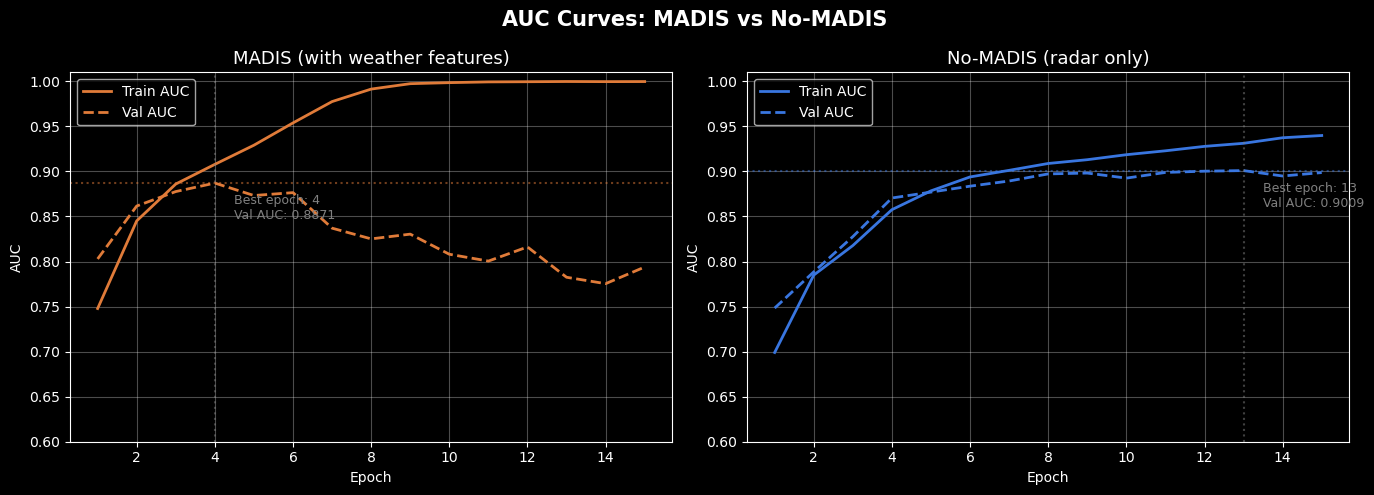

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in zip(
    axes,
    [madis, no_madis],
    ['MADIS (with weather features)', 'No-MADIS (radar only)'],
    ['#e07b39', '#3976e0']
):
    ax.plot(df.index, df['AUC'],     color=color, linewidth=2, label='Train AUC')
    ax.plot(df.index, df['val_AUC'], color=color, linewidth=2, linestyle='--', label='Val AUC')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.set_ylim(0.6, 1.01)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(y=df['val_AUC'].max(), color=color, linestyle=':', alpha=0.5,
               label=f'Best val AUC: {df["val_AUC"].max():.4f}')
    best_epoch = df['val_AUC'].idxmax()
    ax.axvline(x=best_epoch, color='gray', linestyle=':', alpha=0.5)
    ax.annotate(f'Best epoch: {best_epoch}\nVal AUC: {df["val_AUC"].max():.4f}',
                xy=(best_epoch, df['val_AUC'].max()),
                xytext=(best_epoch + 0.5, df['val_AUC'].max() - 0.04),
                fontsize=9, color='gray')

plt.suptitle('AUC Curves: MADIS vs No-MADIS', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Loss Curves

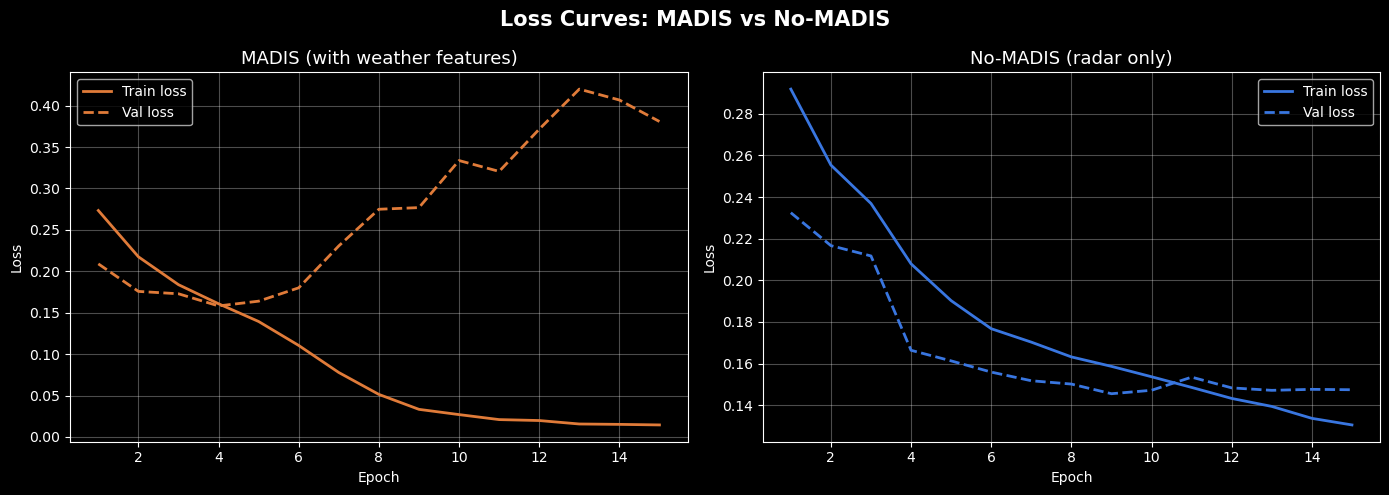

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in zip(
    axes,
    [madis, no_madis],
    ['MADIS (with weather features)', 'No-MADIS (radar only)'],
    ['#e07b39', '#3976e0']
):
    ax.plot(df.index, df['loss'],     color=color, linewidth=2, label='Train loss')
    ax.plot(df.index, df['val_loss'], color=color, linewidth=2, linestyle='--', label='Val loss')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Loss Curves: MADIS vs No-MADIS', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Head-to-Head Validation Metrics

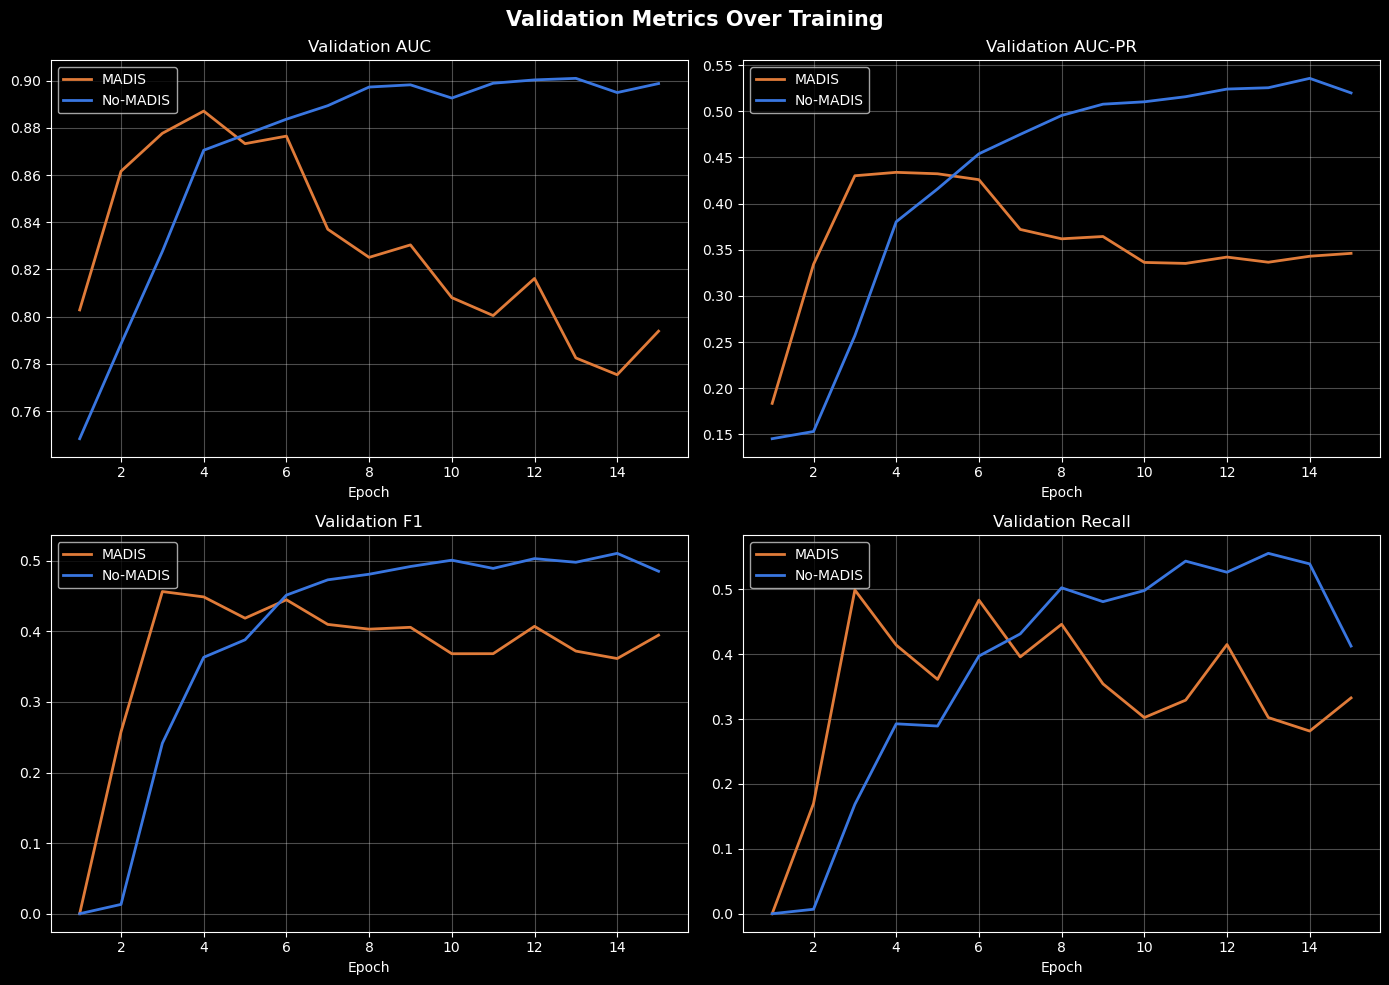

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = [
    ('val_AUC',       'Validation AUC'),
    ('val_AUCPR',     'Validation AUC-PR'),
    ('val_F1',        'Validation F1'),
    ('val_Recall',    'Validation Recall'),
]

for ax, (col, label) in zip(axes, metrics):
    ax.plot(madis.index,    madis[col],    color='#e07b39', linewidth=2, label='MADIS')
    ax.plot(no_madis.index, no_madis[col], color='#3976e0', linewidth=2, label='No-MADIS')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Validation Metrics Over Training', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/val_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Overfitting Analysis

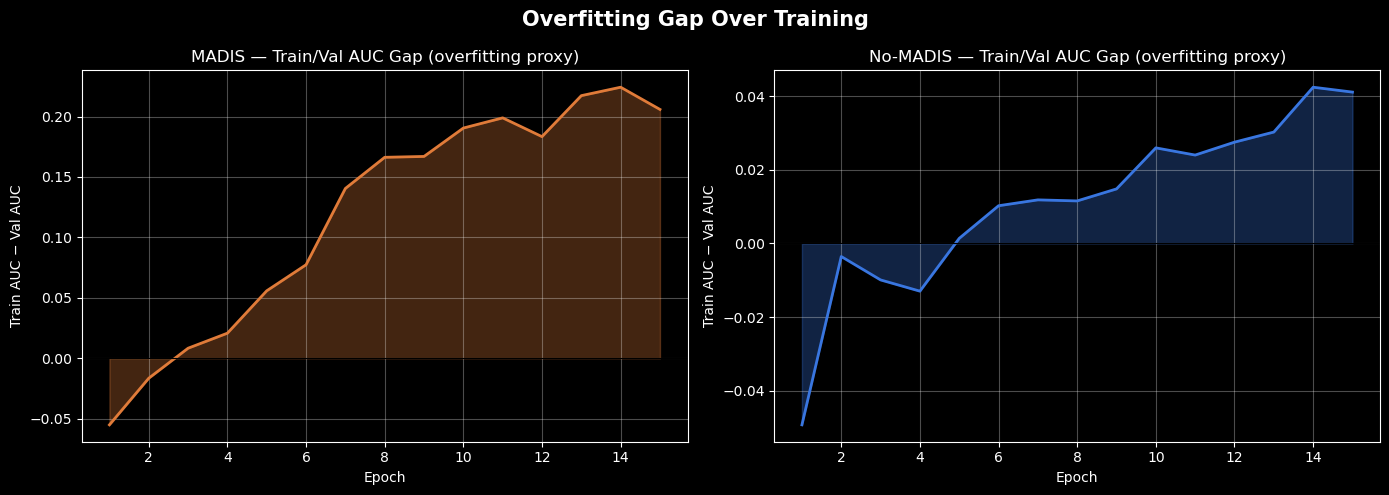

Final train/val AUC gap:
  MADIS:    0.2059
  No-MADIS: 0.0411


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in zip(
    axes,
    [madis, no_madis],
    ['MADIS', 'No-MADIS'],
    ['#e07b39', '#3976e0']
):
    gap = df['AUC'] - df['val_AUC']
    ax.fill_between(df.index, gap, alpha=0.3, color=color)
    ax.plot(df.index, gap, color=color, linewidth=2)
    ax.set_title(f'{title} — Train/Val AUC Gap (overfitting proxy)', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train AUC − Val AUC')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Overfitting Gap Over Training', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Final train/val AUC gap:')
print(f'  MADIS:    {madis["AUC"].iloc[-1] - madis["val_AUC"].iloc[-1]:.4f}')
print(f'  No-MADIS: {no_madis["AUC"].iloc[-1] - no_madis["val_AUC"].iloc[-1]:.4f}')

## Best Epoch Summary

In [7]:
best_madis    = madis.loc[madis['val_AUC'].idxmax()]
best_no_madis = no_madis.loc[no_madis['val_AUC'].idxmax()]

print(f'Best MADIS epoch:    {madis["val_AUC"].idxmax()} / 15')
print(f'Best No-MADIS epoch: {no_madis["val_AUC"].idxmax()} / 15')
print()

best_cols = ['val_AUC', 'val_AUCPR', 'val_F1', 'val_Precision', 'val_Recall', 'val_loss']
best_summary = pd.DataFrame({
    'MADIS (best epoch)':    best_madis[best_cols],
    'No-MADIS (best epoch)': best_no_madis[best_cols],
})
print(best_summary.round(4))

Best MADIS epoch:    4 / 15
Best No-MADIS epoch: 13 / 15

               MADIS (best epoch)  No-MADIS (best epoch)
val_AUC                    0.8871                 0.9009
val_AUCPR                  0.4338                 0.5254
val_F1                     0.4488                 0.4979
val_Precision              0.4898                 0.4510
val_Recall                 0.4142                 0.5557
val_loss                   0.1582                 0.1472


## Findings

### What happened

The MADIS model significantly **overfit** to the training data:
- Train AUC reached **0.9998** by epoch 15, but val AUC dropped to **0.794** — well below its own peak of ~0.887 at epoch 5
- The no-MADIS model generalized much better: train AUC 0.940, val AUC **0.899**, with val loss staying low and stable throughout

### Why the MADIS model overfit

1. **MLP head has more parameters** than maxpool — the extra capacity combined with 7 additional MADIS features gives the model more room to memorize training storms
2. **MADIS features may be too storm-specific** — surface weather readings are highly localized and may correlate with individual training events in ways that don't generalize to 2021–2022
3. **Sparse MADIS coverage** — the model may be learning to over-rely on MADIS when it's available, learning shortcuts rather than generalizable signal

### Conclusion
In this run, MADIS features **hurt** generalization rather than helping. The no-MADIS radar-only model is the stronger performer on held-out data.

## Next Steps

### Fixing MADIS overfitting

1. **Early stopping** — the MADIS model peaked at epoch 5. Add `EarlyStopping(monitor='val_AUC', patience=3)` to stop before degradation sets in
2. **Increase dropout** in the MADIS branch (currently 0.3 in `cnn_baseline.py`) — try 0.5 to force better regularization
3. **Reduce MADIS branch capacity** — try `Dense(32, relu) → Dense(16, relu)` instead of 64→32 to limit memorization
4. **L2 regularization on the MADIS Dense layers** — add `kernel_regularizer=l2(1e-4)` to the MADIS branch layers

### Experimental design improvements

5. **Cross-validate across year splits** — val years 2021–2022 may have different MADIS coverage characteristics than training years; try multiple train/val splits to confirm the overfitting pattern is consistent
6. **Ablation: MLP head without MADIS** — already done (no_madis_comparison), confirms the MLP head alone isn't the issue since it generalizes well without MADIS features
7. **Feature importance** — log which MADIS features have the largest weight norms to understand which (if any) are contributing signal vs noise

### Longer term

8. **More MADIS data** — broader station coverage in later years may reduce the sparsity-driven overfitting
9. **MADIS anomaly features only** — the tier-1 anomaly features (pressure_anomaly_24h, wind_anomaly_24h, instability proxies) may generalize better than raw T0 readings since they capture relative change rather than absolute values

## Deployment Learnings

Notes from getting this training run up on Vast.ai for future reference.

### 1. Download TorNet data in parallel from Zenodo
The `download_tornet_data.py` script downloads years sequentially. On a fast instance (1Gbps+) you leave most bandwidth unused. Next time, kick off parallel downloads — either split years across background processes or modify the script to use concurrent downloads:
```bash
# Example: download multiple years in parallel background jobs
python download_tornet_data.py --years 2013 2014 2015 &
python download_tornet_data.py --years 2016 2017 2018 &
python download_tornet_data.py --years 2019 2020 2021 2022 &
wait
```

### 2. This workload is CPU-bound, not GPU-bound
The bottleneck is NetCDF file loading, not model computation. The RTX 3090 sat mostly idle waiting for data batches. Next time, prioritize instances with **more CPU cores and faster disk I/O** over a bigger GPU. A cheaper GPU instance with 16+ CPU cores and NVMe storage will likely run faster and cost less.

### 3. Steps to verify GPU is visible to TensorFlow/Keras
After installing dependencies, always verify before starting a long run:
```bash
# Check CUDA version first
nvidia-smi

# Verify TensorFlow sees the GPU
python -c "import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))"
# Should print: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Set environment variables before training
export KERAS_BACKEND=tensorflow
export TORNET_ROOT=/workspace/tornet_data
```
For CUDA 12.6: `pip install tensorflow[and-cuda]==2.18.0 keras==3.6.0 --force-reinstall`

### 4. Minimizing result download size
Each run saves 15 checkpoint files (~2.3GB each = 34GB per run). Only the final model and metrics are needed for analysis. After training completes:
```bash
# On the instance — stage only what you need
mkdir /workspace/results
cp <run_folder>/checkpoints/tornadoDetector_015.keras /workspace/results/<name>_015.keras
cp <run_folder>/history.csv /workspace/results/<name>_history.csv
cp <run_folder>/params.json /workspace/results/<name>_params.json

# Compress before downloading
tar -czf results.tar.gz /workspace/results

# Download from local machine
scp -P <PORT> -i ~/.ssh/id_ed25519 root@<IP>:/workspace/results.tar.gz ./
```
This reduces ~68GB to ~5GB before compression.